# Met Office PyEarthTools Machine Learning Demo Project

## Setup

In [1]:
import pyearthtools
from pyearthtools import data, pipeline

import site_archive_met_office

ROOT_DIRECTORIES: {'ERA5lowres': '/data/users/dscop/weatherbench/5.625deg/', 'MOGLOBAL': '/data/users/dscop/pyearthtools_data/mo_global/', 'MOUKV': '/data/users/dscop/pyearthtools_data/mo_ukv/'}


In [2]:
print(site_archive_met_office.get_root_directories())

{'ERA5lowres': '/data/users/dscop/weatherbench/5.625deg/', 'MOGLOBAL': '/data/users/dscop/pyearthtools_data/mo_global/', 'MOUKV': '/data/users/dscop/pyearthtools_data/mo_ukv/'}


## Create UKV PyEarthTools Data Accessor

In [20]:
variables = ['air_temperature', 'air_pressure_at_sea_level', 'x_wind', 'y_wind', 'specific_humidity', 'surface_altitude']
moglobal_accessor = pyearthtools.data.archive.MOGLOBAL(variables=variables)
moglobal_accessor

MOGLOBAL
	Description                    Met Office Global (subset)
		 range                          '2018'
		 Documentation                  'https://www.metoffice.gov.uk/binaries/content/assets/metofficegovuk/pdf/data/global-nwp-asdi-datasheet.pdf'


	Initialisation                 
		 level_value                    None
		 variables                      ['air_temperature', 'air_pressure_at_sea_level', 'x_wind', 'y_wind', 'specific_humidity', 'surface_altitude']
	Transforms                     
		 StandardCoordinateNames        {'latitude': "['lat', 'Latitude', 'yt_ocean', 'yt']", 'longitude': "['lon', 'Longitude', 'xt_ocean', 'xt']", 'replacement_dictionary': 'None', 'time': "['Time']"}
		 Trim                           {'__args': '()', 'variables': "['air_temperature', 'air_pressure_at_sea_level', 'x_wind', 'y_wind', 'specific_humidity', 'surface_altitude']"}

In [21]:
sample_date = '2018-01-01T00'
moglobal_sample_date = moglobal_accessor[sample_date]
moglobal_sample_date

Matching files: [PosixPath('/data/users/dscop/pyearthtools_data/mo_global/prods_op_gl-mn_20180101_00_000.calc.nc')]


<xarray.Dataset> Size: 118MB
Dimensions:                    (time: 1, latitude: 1920, longitude: 2560,
                                latitude_0: 1921, longitude_0: 2560)
Coordinates:
  * latitude                   (latitude) float32 8kB -89.95 -89.86 ... 89.95
  * longitude                  (longitude) float32 10kB 0.07031 0.2109 ... 359.9
    forecast_period            timedelta64[ns] 8B ...
    forecast_reference_time    datetime64[ns] 8B ...
  * time                       (time) datetime64[ns] 8B 2018-01-01
    height                     float64 8B ...
    forecast_period_0          timedelta64[ns] 8B ...
    time_0                     datetime64[ns] 8B ...
  * latitude_0                 (latitude_0) float32 8kB -90.0 -89.91 ... 90.0
  * longitude_0                (longitude_0) float32 10kB 0.0 0.1406 ... 359.9
    height_0                   float64 8B ...
Data variables:
    air_temperature            (time, latitude, longitude) float32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    air_pressure_at_sea_level  (time, latitude, longitude) float32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    y_wind                     (time, latitude_0, longitude_0) float32 20MB dask.array<chunksize=(1, 1921, 2560), meta=np.ndarray>
    specific_humidity          (time, latitude, longitude) float32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    surface_altitude           (time, latitude, longitude) float32 20MB dask.array<chunksize=(1, 1920, 2560), meta=np.ndarray>
    x_wind                     (time, latitude_0, longitude_0) float32 20MB dask.array<chunksize=(1, 1921, 2560), meta=np.ndarray>
Attributes:
    source:       Data from Met Office Unified Model
    um_version:   10.6
    Conventions:  CF-1.7

## Visualise the data

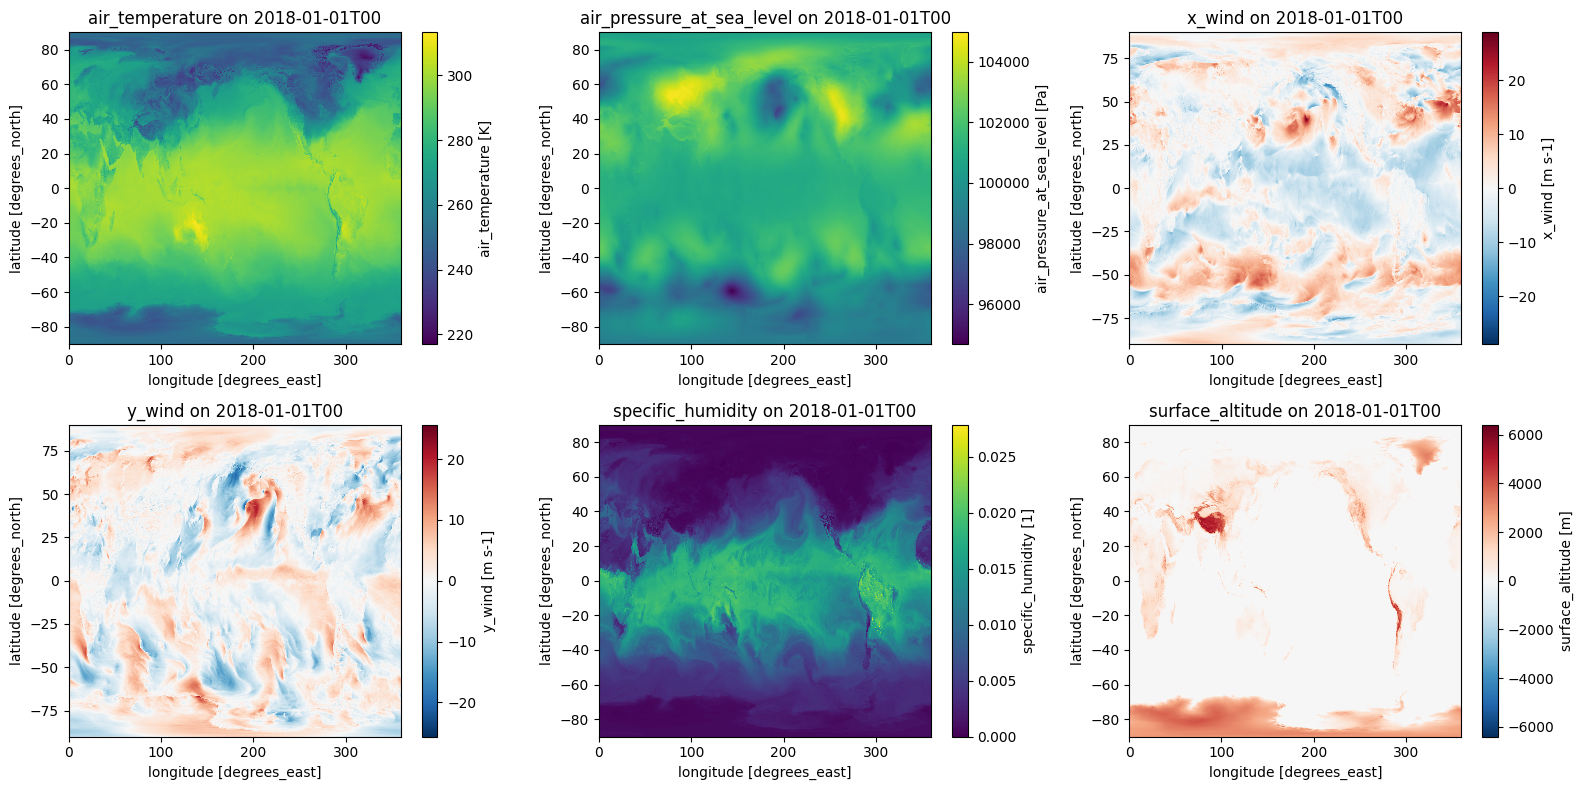

In [22]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 3, figsize=(16, 8))

for ax, var in zip(axs.flat, variables):
    moglobal_sample_date[var].plot(ax=ax)
    ax.set_title(f'{var} on {sample_date}')

plt.tight_layout()
plt.show()

## Data Processing Pipeline

In [23]:
import os
workdir = os.getcwd()

In [62]:
data_pipeline = pyearthtools.pipeline.Pipeline(
    moglobal_accessor,
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="-180-180"), 
    
    # Uncomment the line below if working with multi-level data
    #pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten("level"),
    
    # Input = 1 sample from time T=0 hours. Output = T+6.
    pyearthtools.pipeline.modifications.TemporalRetrieval( concat=True, samples=((0, 1), (6, 1)) ),    
    
    #pyearthtools.pipeline.operations.xarray.normalisation.MagicNorm(cache_dir=workdir),  # Incremental normalisation calculator
    
    pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
    pyearthtools.pipeline.operations.numpy.reshape.Rearrange('t h w c -> t c h w'), # channel time height width -> time channel height width
    pyearthtools.pipeline.operations.numpy.reshape.Squeeze(axis=0),

    #sampler=pyearthtools.pipeline.samplers.Default(),
    #iterator=pyearthtools.pipeline.iterators.DateRange(2018, 2019, interval='6 hours')
)
# data_pipeline

In [63]:
result = data_pipeline['2018-03-01T00']
input = result[0]
targets = result[1]

print(input.dims)
print(input.info())

Matching files: [PosixPath('/data/users/dscop/pyearthtools_data/mo_global/prods_op_gl-mn_20180301_00_000.calc.nc')]
Matching files: [PosixPath('/data/users/dscop/pyearthtools_data/mo_global/prods_op_gl-mn_20180301_06_000.calc.nc')]


TypeError: len() of unsized object

In [54]:
for data in data_pipeline:
    print(data)


Matching files: [PosixPath('/data/users/dscop/pyearthtools_data/mo_global/prods_op_gl-mn_20180101_00_000.calc.nc')]
Matching files: [PosixPath('/data/users/dscop/pyearthtools_data/mo_global/prods_op_gl-mn_20180101_06_000.calc.nc')]


TypeError: len() of unsized object

In [26]:
for dataset in data_pipeline:
    input, target = dataset
    for var in input.variables:
        print(f"{var} input shape: {input[var].shape}, target shape: {target[var].shape}")


Matching files: [PosixPath('/data/users/dscop/pyearthtools_data/mo_global/prods_op_gl-mn_20180101_00_000.calc.nc')]


ValueError: too many values to unpack (expected 2)

In [27]:
data = data_pipeline['2018-01-01T00']

Matching files: [PosixPath('/data/users/dscop/pyearthtools_data/mo_global/prods_op_gl-mn_20180101_00_000.calc.nc')]


In [28]:
import pyearthtools.training

KeyboardInterrupt: 

In [ ]:
splits = {
    'train_split': pyearthtools.pipeline.iterators.DateRange('2018-01-01T00', '2018-03-31T00', interval='6 hours'),
    'valid_split': pyearthtools.pipeline.iterators.DateRange('2018-04-01T00', '2018-06-30T00', interval = '6 hours'),
}

# If you encounter memory problems, set the batch size to a lower number, or 1
# If you encounter CPU / multithreading issues, set num_workers to a lower number, or 0
# 0 is a special number which means 'use the main process', whereas '1' will spawn 1 worker
datamodule = pyearthtools.training.data.lightning.PipelineLightningDataModule(
    data_pipeline,
    **splits,
    **{'num_workers': 4, 'batch_size': 8}
)

datamodule

PipelineLightningDataModule
	Initialisation                 Pytorch Lightning DataModule.
		 batch_size                     8
		 iterator_dataset               False
		 num_workers                    4
		 pipelines                      {'Pipeline': {'__args': '(MOGLOBAL\n\tDescription                    Met Office Global (subset)\n\t\t range                          \'2018\'\n\t\t Documentation                  \'https://www.metoffice.gov.uk/binaries/content/assets/metofficegovuk/pdf/data/global-nwp-asdi-datasheet.pdf\'\n\n\n\tInitialisation                 \n\t\t level_value                    None\n\t\t variables                      [\'t2m\', \'air_pressure_at_sea_level\', \'u\', \'v\', \'specific_humiditysurface_altitude\']\n\tTransforms                     \n\t\t StandardCoordinateNames        {\'latitude\': "[\'lat\', \'Latitude\', \'yt_ocean\', \'yt\']", \'longitude\': "[\'lon\', \'Longitude\', \'xt_ocean\', \'xt\']", \'replacement_dictionary\': \'None\', \'time\': "[\'Time\']"}, StandardLongitude\n\tInitialisation                 Standardise format of longitude.\n\t\t longitude_name                 \'longitude\'\n\t\t type                           \'-180-180\', TemporalRetrieval\n\tInitialisation                 Retrieve a sequence of samples from `SequenceRetrieval`,\n\t\t concat                         True\n\t\t delta_unit                     None\n\t\t merge_function                 None\n\t\t merge_kwargs                   None\n\t\t samples                        ((0, 1), (6, 1)), MagicNorm\n\tInitialisation                 Automatically normalise any variables\n\t\t cache_dir                      \'/home/users/john.pill/Projects/PyEarthTools/notebooks/tutorial\'\n\t\t samples_needed                 20, ToNumpy\n\tInitialisation                 Convert xarray objects to np.ndarray\'s\n\t\t reference_dataset              None\n\t\t run_parallel                   False\n\t\t saved_records                  None\n\t\t warn                           True, Rearrange\n\tInitialisation                 Operation to rearrange data using einops\n\t\t rearrange                      \'c t h w -> t c h w\'\n\t\t rearrange_kwargs               None\n\t\t reverse_rearrange              None\n\t\t skip                           False)', 'exceptions_to_ignore': 'None', 'iterator': {'DateRange': {'end': '2019', 'interval': "'6 hours'", 'start': '2018'}}, 'sampler': {'Default': {}}}}
		 train_split                    {'DateRange': {'end': "'2018-03-31T00'", 'interval': "'6 hours'", 'start': "'2018-01-01T00'"}}
		 valid_split                    {'DateRange': {'end': "'2018-06-30T00'", 'interval': "'6 hours'", 'start': "'2018-04-01T00'"}}

: 

### Scaling
Becuase our data was split into training and target data inside the pipeline above using the TemporalRetrieval method, we need to use the pipeline to access and scale just the training data.

In [18]:
sample_date = '2018-06-01T00'
input_array, target_array = moglobal_data_pipeline[sample_date]
print("Input array shape:", input_array.shape)
print("Target array shape:", target_array.shape)

Matching files: [PosixPath('/data/users/dscop/pyearthtools_data/mo_global/prods_op_gl-mn_20180601_00_000.calc.nc')]
Matching files: []
Matching files: []


/home/users/john.pill/Projects/PyEarthTools/packages/met_office_site_archive/src/site_archive_met_office/MOGLOBAL.py:115: IndexWarning: Data exists at 6 hourly intervals, 2018-06-01T01 is thus invalid. Rounding down...
  warnings.warn(


DataNotFoundError: Data with args: (Petdt('2018-06-01T01'),) could not be found.

#### Test the pipeline

In [ ]:
# Let's provide the moglobal_training_samples a sample date. 
sample_pipeline_date = moglobal_training_samples['2018-01-01T03']

# Print the Input and Target samples generated by the pipeline
print("Input sample:", sample_pipeline_date[0].time.data)
print("Target sample:", sample_pipeline_date[1].time.data)

TypeError: len() of unsized object